# 1. Visualize raw data

Load **one** parquet file from `work_dir/raw_data` and inspect its columns, sample rows, and basic plots.

### Raw data and data directory format

**Raw data (each parquet file)**  
Each file is a table with one row per (time, frequency) detection from a spectrum scan:

| Column         | Meaning |
|----------------|--------|
| **timestamp**  | Unix time (seconds since 1970-01-01 UTC) when the scan was taken. |
| **freqs**      | Frequency in **Hz** where activity was detected (e.g. 5.5e9 for 5.5 GHz). |
| **trace_max**  | Received power in **dBm** at that frequency (e.g. -85). Used with `pow_threshold_dbm` to keep only "strong enough" detections. |
| **center_freq**| Center frequency in **Hz** of the band being scanned (identifies the band, e.g. 195e6, 5.5e9). |

**Data directory**  
Parquet files live under **`work_dir/raw_data`**. File naming: `Band_<band>MHz_WO_meta_<YYYYMMDD>_<HHMM>.parquet`. Use the **transform** module (task `transform`) to build CSVs under `work_dir/csvs`.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

Columns: ['timestamp', 'freqs', 'trace_max', 'center_freq']
Shape: (5017, 4)

Dtypes:
timestamp      float64
freqs          float64
trace_max      float64
center_freq      int64
dtype: object

First 5 rows:


,timestamp,freqs,trace_max,center_freq
0,1.769906e+09,1.915234e+08,-109.80,195000000
1,1.769906e+09,1.915258e+08,-109.85,195000000
2,1.769906e+09,1.916894e+08,-109.96,195000000
3,1.769906e+09,1.983032e+08,-105.16,195000000
4,1.769906e+09,1.983056e+08,-101.53,195000000



Basic stats:


,timestamp,freqs,trace_max,center_freq
count,5.017000e+03,5.017000e+03,5017.000000,5017.0
mean,1.769906e+09,1.995761e+08,-109.214236,195000000.0
std,9.104060e+00,1.818530e+06,1.045099,0.0
min,1.769906e+09,1.755737e+08,-110.000000,195000000.0
25%,1.769906e+09,1.987621e+08,-109.760000,195000000.0
50%,1.769906e+09,1.992529e+08,-109.460000,195000000.0
75%,1.769906e+09,1.999658e+08,-108.990000,195000000.0
max,1.769906e+09,2.037377e+08,-100.060000,195000000.0


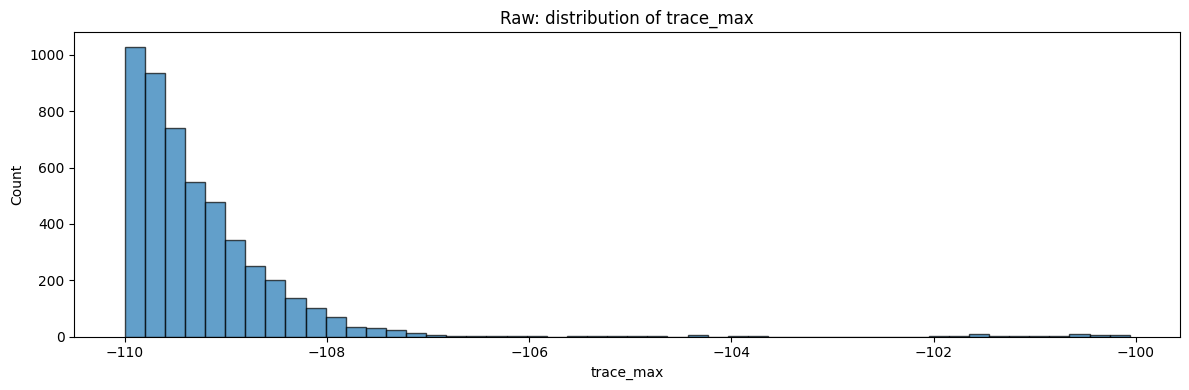

In [7]:
# Path to a single parquet file under work_dir/raw_data (or absolute)
single_parquet_path = "../work_dir/raw_data/Band_195MHz_WO_meta_20260201_0037.parquet"  # change as needed

raw_file = Path(single_parquet_path)
if not raw_file.exists():
    print(f"File not found: {raw_file}")
else:
    df_raw = pd.read_parquet(raw_file)
    print("Columns:", list(df_raw.columns))
    print("Shape:", df_raw.shape)
    print("\nDtypes:")
    print(df_raw.dtypes)
    print("\nFirst 5 rows:")
    display(df_raw.head())
    print("\nBasic stats:")
    display(df_raw.describe())

    cols = list(df_raw.columns)
    pwr_col = next((c for c in cols if "trace" in c.lower() or "max" in c.lower() or "power" in c.lower()), cols[2] if len(cols) >= 3 else None)

    if pwr_col and len(df_raw) > 0:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.hist(df_raw[pwr_col].dropna(), bins=50, edgecolor="black", alpha=0.7)
        ax.set_xlabel(pwr_col)
        ax.set_ylabel("Count")
        ax.set_title(f"Raw: distribution of {pwr_col}")
        plt.tight_layout()
        plt.show()
    else:
        print("Could not infer power column for plot. Check column names above.")